# 🛍️ Shopping Mall Customer Segmentation
## Member X — Gaussian Mixture Model (GMM)
**Dataset:** Shopping_Mall_Customer_Segmentation_Data_.csv  
**Algorithm:** Gaussian Mixture Model (GMM)  
**Task:** Unsupervised Learning — Customer Segmentation

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score

import warnings
warnings.filterwarnings('ignore')

print('Libraries imported successfully!')

Libraries imported successfully!


## 2. Load Pre-processed Data
> Data was already cleaned and scaled in `step0_eda_preprocessing_no_pca.ipynb`.
> This GMM version uses **scaled features directly** without PCA.


In [2]:
import numpy as np
import pandas as pd

X_scaled = np.load("data/X_scaled.npy")

df_clean = pd.read_csv("data/data_preprocessed.csv")
df = pd.read_csv("data/Shopping_Mall_Customer_Segmentation_Data_.csv")

print('✅ Loaded X_scaled.npy shape:', X_scaled.shape)
print('✅ Loaded data_preprocessed.csv shape:', df_clean.shape)
print('✅ Loaded original CSV shape:', df.shape)
print('✅ PCA is NOT used in this notebook')

✅ Loaded X_scaled.npy shape: (15079, 4)
✅ Loaded data_preprocessed.csv shape: (15079, 4)
✅ Loaded original CSV shape: (15079, 5)
✅ PCA is NOT used in this notebook


In [3]:
from sklearn.preprocessing import StandardScaler


features_for_clustering = ['Age', 'Annual Income', 'Spending Score']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean[features_for_clustering])
print('✅ Feature shape for clustering:', X_scaled.shape) 

✅ Feature shape for clustering: (15079, 3)


## 3. Select Optimal Number of Clusters (BIC)
> GMM does not use bandwidth like MeanShift.  
> Instead, we test different values of **K** and choose the best one using **BIC** (lower is better).


In [4]:
bic_scores = []
aic_scores = []
k_range = range(2, 10)

for k in k_range:
    model = GaussianMixture(
        n_components=k,
        covariance_type='diag',
        random_state=42,
        n_init=5
    )
    model.fit(X_scaled)
    bic_scores.append(model.bic(X_scaled))
    aic_scores.append(model.aic(X_scaled))

best_k = list(k_range)[np.argmin(bic_scores)]
print(f'✅ Best K selected by BIC: {best_k}')

✅ Best K selected by BIC: 9


In [5]:
best_k = 4

## 4. BIC / AIC Visualization

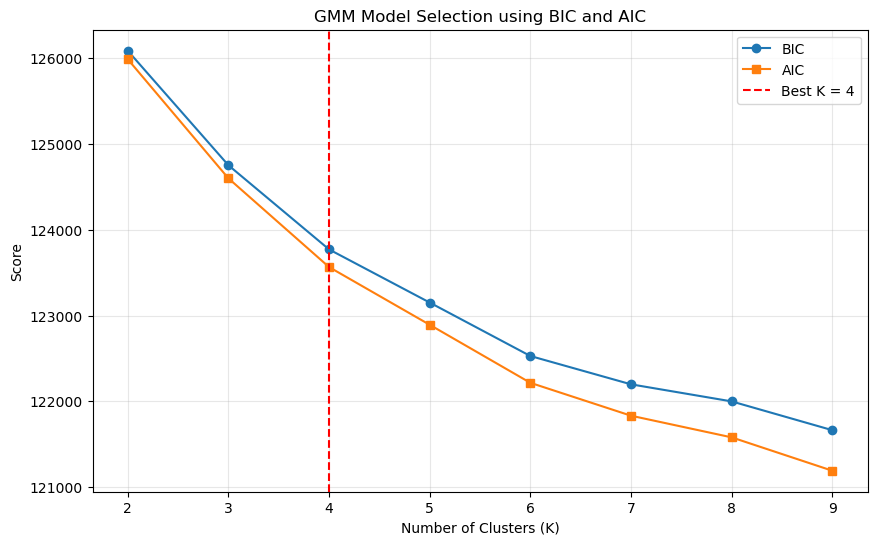

In [6]:
plt.figure(figsize=(10, 6))
plt.plot(list(k_range), bic_scores, marker='o', label='BIC')
plt.plot(list(k_range), aic_scores, marker='s', label='AIC')
plt.axvline(x=best_k, color='red', linestyle='--', label=f'Best K = {best_k}')

plt.title('GMM Model Selection using BIC and AIC')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Score')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 5. Train GMM Model
> Train the final Gaussian Mixture Model using the selected number of clusters.


In [7]:
gmm = GaussianMixture(
    n_components=best_k,
    covariance_type='diag',
    random_state=42,
    n_init=5
)
gmm.fit(X_scaled)

cluster_labels = gmm.predict(X_scaled)
cluster_probs = gmm.predict_proba(X_scaled)
df_clean['Cluster'] = cluster_labels
n_clusters = len(np.unique(cluster_labels))

print(f'Number of clusters found by GMM: {n_clusters}')
print('\nCluster Distribution:')
unique, counts = np.unique(cluster_labels, return_counts=True)
for c, cnt in zip(unique, counts):
    print(f'  Cluster {c}: {cnt} customers ({cnt/len(df)*100:.1f}%)')

df_clean['Cluster'] = cluster_labels
df['Cluster'] = cluster_labels

Number of clusters found by GMM: 4

Cluster Distribution:
  Cluster 0: 3844 customers (25.5%)
  Cluster 1: 3739 customers (24.8%)
  Cluster 2: 3726 customers (24.7%)
  Cluster 3: 3770 customers (25.0%)


## 6. Evaluation Metrics

In [8]:
sil = silhouette_score(X_scaled, cluster_labels)
dbi = davies_bouldin_score(X_scaled, cluster_labels)

print('=' * 45)
print('        GMM EVALUATION METRICS')
print('=' * 45)
print(f'  Best K Selected     : {best_k}')
print(f'  Silhouette Score    : {sil:.4f}  (closer to 1 = better)')
print(f'  Davies-Bouldin Index: {dbi:.4f}  (closer to 0 = better)')
print(f'  Final BIC Score     : {gmm.bic(X_scaled):.2f}')
print(f'  Final AIC Score     : {gmm.aic(X_scaled):.2f}')
print('=' * 45)

        GMM EVALUATION METRICS
  Best K Selected     : 4
  Silhouette Score    : 0.2554  (closer to 1 = better)
  Davies-Bouldin Index: 1.2792  (closer to 0 = better)
  Final BIC Score     : 123770.69
  Final AIC Score     : 123564.92


## 7. Cluster Visualization (Original Feature Space)
> Since PCA is not used, we visualise the clustering result directly in the original scaled feature space.


In [9]:
feature_cols = ['Annual Income', 'Spending Score', 'Age']

X_vis = df_clean[feature_cols].values

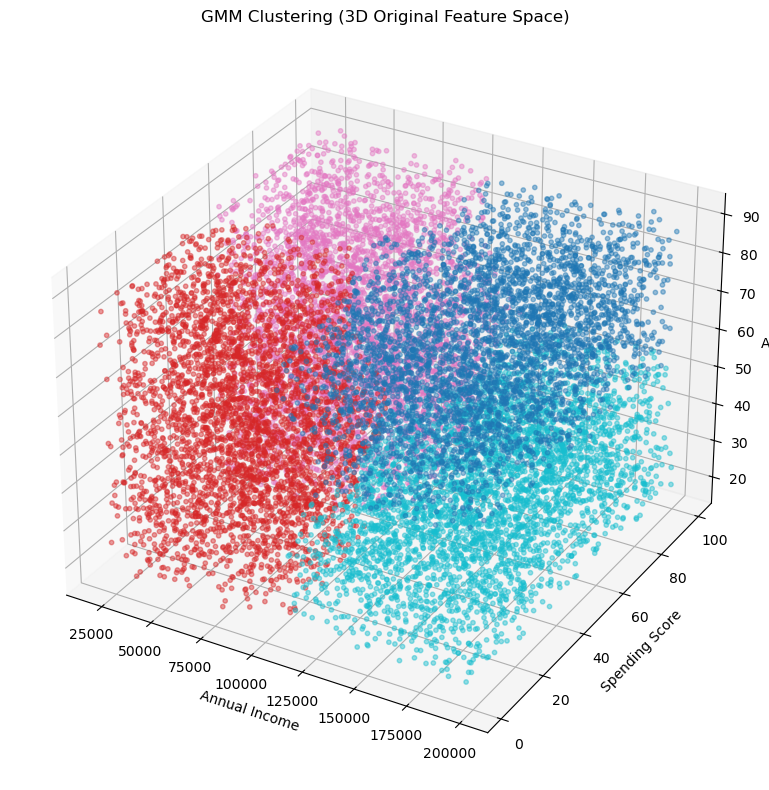

In [10]:
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    df['Annual Income'],
    df['Spending Score'],
    df['Age'],
    c=cluster_labels,
    cmap='tab10',
    s=10,
    alpha=0.45
)

ax.set_xlabel('Annual Income')
ax.set_ylabel('Spending Score')
ax.set_zlabel('Age')
ax.set_title('GMM Clustering (3D Original Feature Space)')
plt.tight_layout()
plt.show()

## 8. Cluster Profile Analysis

In [11]:
profile = df.groupby('Cluster')[['Age', 'Annual Income', 'Spending Score']].mean().round(2)
profile['Count'] = df.groupby('Cluster')['Age'].count()
profile['% of Total'] = (profile['Count'] / len(df) * 100).round(2)
print('Cluster Profiles:')
profile

Cluster Profiles:


,Age,Annual Income,Spending Score,Count,% of Total
Cluster,,,,,
0,73.31,153260.73,50.58,3844,25.49
1,53.99,63974.47,25.04,3739,24.80
2,53.58,64516.42,76.10,3726,24.71
3,35.50,155461.52,50.74,3770,25.00


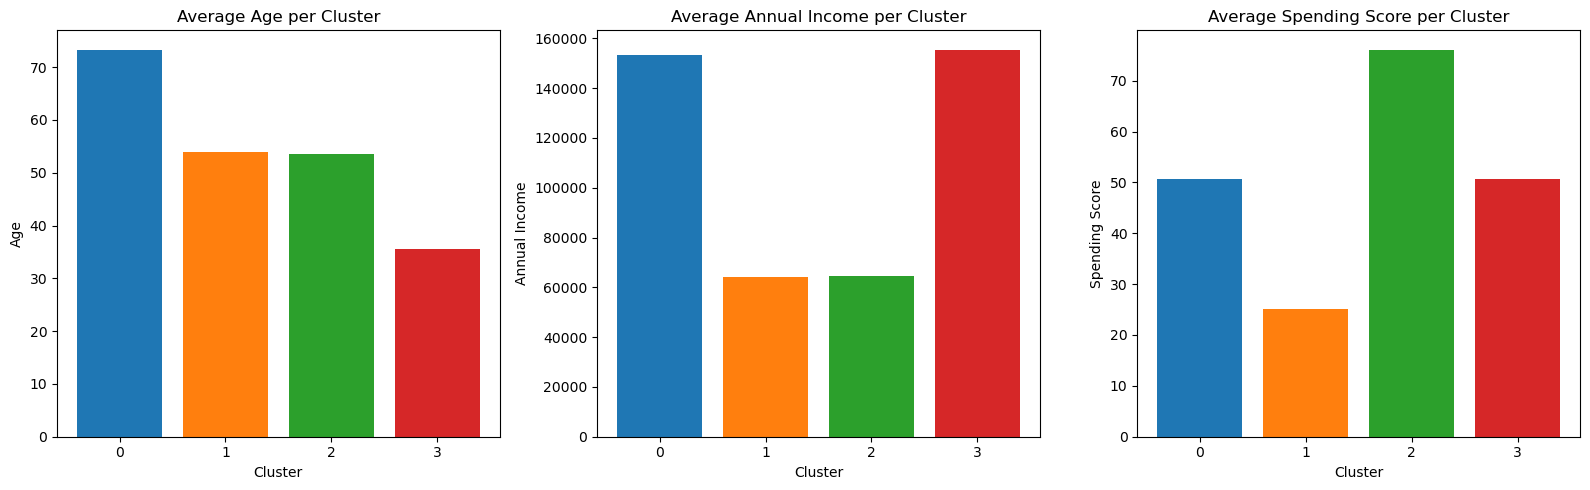

In [12]:
# Bar chart of cluster averages
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
features = ['Age', 'Annual Income', 'Spending Score']
palette_bar = sns.color_palette('tab10', n_clusters)

for i, feat in enumerate(features):
    cluster_means = df.groupby('Cluster')[feat].mean()
    axes[i].bar(cluster_means.index.astype(str), cluster_means.values, color=palette_bar)
    axes[i].set_title(f'Average {feat} per Cluster')
    axes[i].set_xlabel('Cluster')
    axes[i].set_ylabel(feat)

plt.tight_layout()
plt.savefig('gmm_cluster_profiles.png', dpi=150)
plt.show()

## 9. Membership Probability Analysis

In [13]:
prob_df = pd.DataFrame(cluster_probs, columns=[f'Prob_Cluster_{i}' for i in range(n_clusters)])
prob_df['Predicted_Cluster'] = cluster_labels

print('First 10 customers with cluster membership probabilities:')
prob_df.head(10)

First 10 customers with cluster membership probabilities:


,Prob_Cluster_0,Prob_Cluster_1,Prob_Cluster_2,Prob_Cluster_3,Predicted_Cluster
0,0.000678,3.943427e-06,0.012757,0.986562,3
1,0.685261,7.699588e-08,0.000987,0.313752,0
2,0.012172,5.565984e-03,0.981243,0.001018,2
3,0.000001,2.079349e-01,0.784644,0.007420,2
4,0.000114,4.131074e-05,0.009337,0.990508,3
5,0.024348,3.409537e-03,0.000536,0.971707,3
6,0.000288,1.496144e-03,0.000134,0.998083,3
7,0.000003,9.844083e-01,0.001306,0.014283,1
8,0.004808,9.611102e-01,0.034081,0.000001,1
9,0.006180,9.932430e-01,0.000082,0.000494,1


## 10. Summary

In [14]:
print('=' * 55)
print('         GMM CLUSTERING — FINAL SUMMARY')
print('=' * 55)
print(f'  Algorithm             : Gaussian Mixture Model (GMM)')
print(f'  Best K Selected       : {best_k}')
print(f'  Covariance Type       : diag')
print(f'  Total Customers       : {len(df)}')
print(f'  Silhouette Score      : {sil:.4f}')
print(f'  Davies-Bouldin Index  : {dbi:.4f}')
print(f'  Final BIC Score       : {gmm.bic(X_scaled):.2f}')
print('=' * 55)
print('\nKey advantage of GMM:')
print('  - Provides soft clustering using membership probabilities')
print('  - Can model overlapping clusters better than K-Means')


         GMM CLUSTERING — FINAL SUMMARY
  Algorithm             : Gaussian Mixture Model (GMM)
  Best K Selected       : 4
  Covariance Type       : diag
  Total Customers       : 15079
  Silhouette Score      : 0.2554
  Davies-Bouldin Index  : 1.2792
  Final BIC Score       : 123770.69

Key advantage of GMM:
  - Provides soft clustering using membership probabilities
  - Can model overlapping clusters better than K-Means


In [15]:

df_clean['Cluster'] = cluster_labels 


cluster_profiles = df_clean.groupby('Cluster').mean()

print("=============================================")
print("          CUSTOMER CLUSTER PROFILES")
print("=============================================")
print(cluster_profiles)
print("=============================================")

print("\nNumber of customers in each cluster:")
print(df_clean['Cluster'].value_counts())

          CUSTOMER CLUSTER PROFILES
               Age    Gender  Annual Income  Spending Score
Cluster                                                    
0        73.313736  0.501821  153260.727367       50.579084
1        53.989035  0.512436   63974.474726       25.039048
2        53.580247  0.504563   64516.419216       76.096082
3        35.499204  0.496021  155461.517507       50.740053

Number of customers in each cluster:
Cluster
0    3844
3    3770
1    3739
2    3726
Name: count, dtype: int64


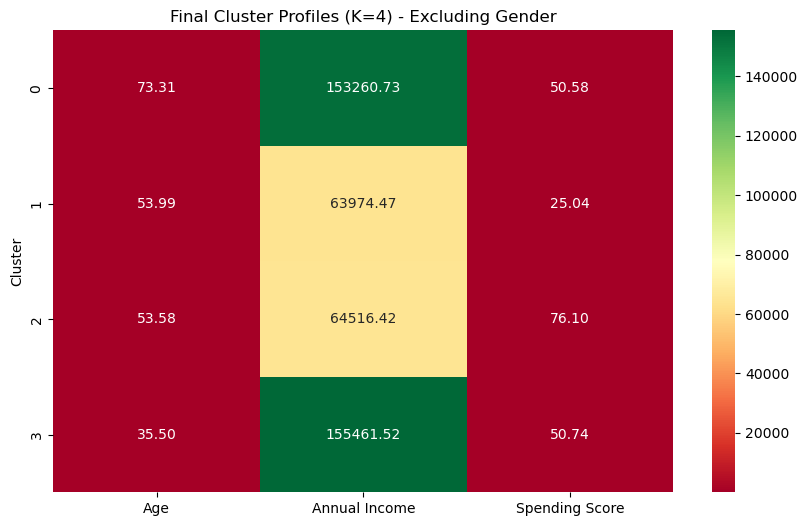

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

plot_features = ['Age', 'Annual Income', 'Spending Score']
display_profiles = df_clean.groupby('Cluster')[plot_features].mean()

plt.figure(figsize=(10, 6))
sns.heatmap(display_profiles, annot=True, cmap='RdYlGn', fmt='.2f')

plt.title('Final Cluster Profiles (K=4) - Excluding Gender')
plt.show()

---
# 🔮 Predict Customer Segment
> Enter a new customer's details below and the trained model will predict which segment they belong to.


In [17]:
# ============================================================
#  ✏️  ENTER CUSTOMER DETAILS HERE
# ============================================================
input_age            = int(input('Enter Age           : '))
input_gender         = input('Enter Gender        (Male/Female): ').strip().capitalize()
input_annual_income  = float(input('Enter Annual Income : '))
input_spending_score = float(input('Enter Spending Score (1-100): '))

gender_encoded = 0 if input_gender == 'Female' else 1

# original input
new_customer = np.array([[input_age, input_annual_income, input_spending_score]])

# predict in scaled feature space
new_customer_scaled = scaler.transform(new_customer)
predicted_cluster = gmm.predict(new_customer_scaled)[0]
membership_probs  = gmm.predict_proba(new_customer_scaled)[0]

# profile from original feature space
cluster_profile = df[df['Cluster'] == predicted_cluster][['Age', 'Annual Income', 'Spending Score']].mean()
cluster_size = (df['Cluster'] == predicted_cluster).sum()

print()
print('=' * 55)
print('             GMM — PREDICTION RESULT')
print('=' * 55)
print(f'  Input  → Age: {input_age}, Gender: {input_gender}')
print(f'           Annual Income: {input_annual_income:,.0f}')
print(f'           Spending Score: {input_spending_score:.1f}')
print()
print(f'   Predicted Cluster : {predicted_cluster}')
print(f'   Cluster Size      : {cluster_size} customers')
print()
print('  Cluster Membership Probabilities:')
for i, prob in enumerate(membership_probs):
    print(f'    Cluster {i}: {prob:.4f}')
print()
print('  Cluster Average Profile:')
print(f'    Average Age           : {cluster_profile["Age"]:.1f}')
print(f'    Average Annual Income : {cluster_profile["Annual Income"]:,.0f}')
print(f'    Average Spending Score: {cluster_profile["Spending Score"]:.1f}')
print('=' * 55)

Enter Age           :  60
Enter Gender        (Male/Female):  male
Enter Annual Income :  80000
Enter Spending Score (1-100):  60



             GMM — PREDICTION RESULT
  Input  → Age: 60, Gender: Male
           Annual Income: 80,000
           Spending Score: 60.0

   Predicted Cluster : 2
   Cluster Size      : 3726 customers

  Cluster Membership Probabilities:
    Cluster 0: 0.0443
    Cluster 1: 0.1205
    Cluster 2: 0.8283
    Cluster 3: 0.0069

  Cluster Average Profile:
    Average Age           : 53.6
    Average Annual Income : 64,516
    Average Spending Score: 76.1


In [18]:
cluster_data = df[df['Cluster'] == predicted_cluster][['Age','Gender', 'Annual Income', 'Spending Score']]

print("\n  Cluster Range:")
print(f"    Age Range           : {cluster_data['Age'].min()} - {cluster_data['Age'].max()}")
print(f"    Annual Income Range : {cluster_data['Annual Income'].min():,.0f} - {cluster_data['Annual Income'].max():,.0f}")
print(f"    Spending Score Range: {cluster_data['Spending Score'].min():.0f} - {cluster_data['Spending Score'].max():.0f}")


  Cluster Range:
    Age Range           : 18 - 90
    Annual Income Range : 20,022 - 123,067
    Spending Score Range: 51 - 100


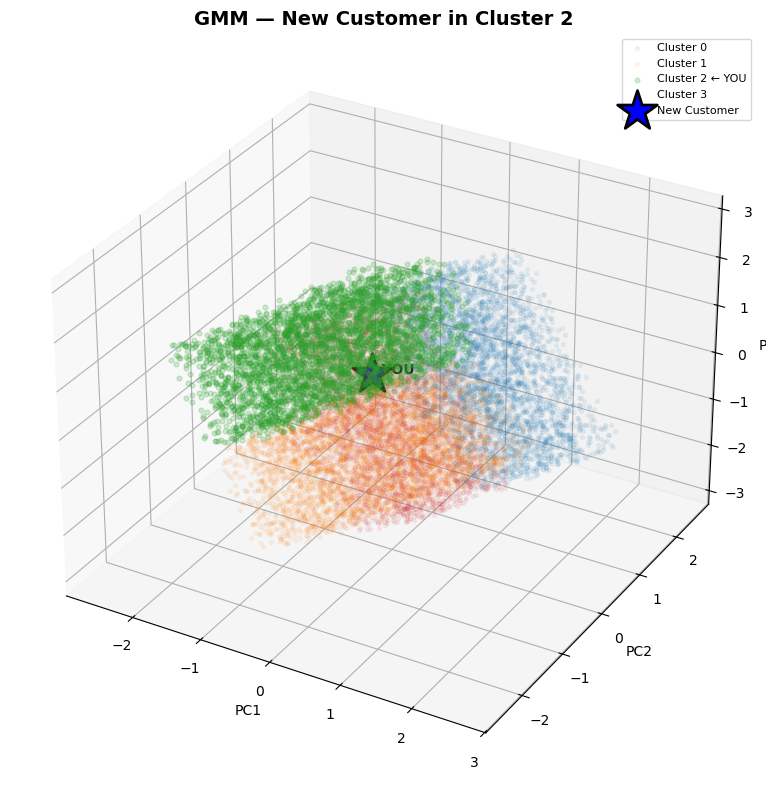

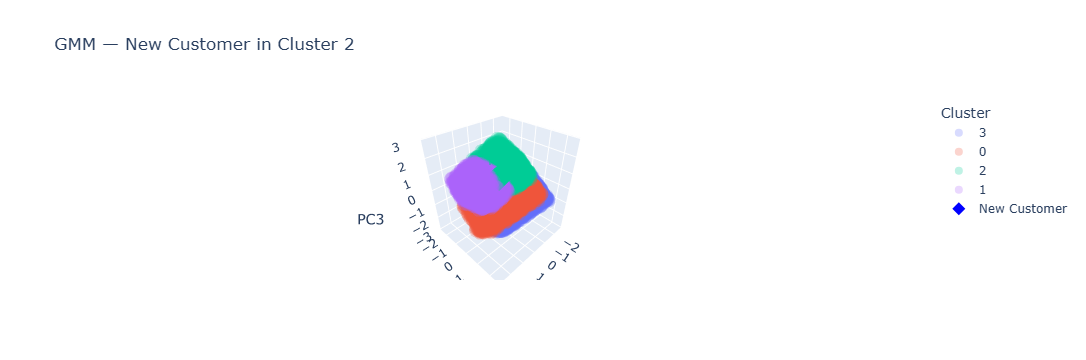

In [19]:
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import pandas as pd

# ============================================================
#  PCA for 3D visualization only
# ============================================================
pca_3d = PCA(n_components=3)

X_3d = pca_3d.fit_transform(X_scaled)
new_3d = pca_3d.transform(new_customer_scaled)

# ============================================================
#  3D PLOT
# ============================================================
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

palette = sns.color_palette('tab10', n_clusters)

for c in range(n_clusters):
    mask = cluster_labels == c

    alpha = 0.20 if c == predicted_cluster else 0.07
    size = 12 if c == predicted_cluster else 8

    ax.scatter(
        X_3d[mask, 0],
        X_3d[mask, 1],
        X_3d[mask, 2],
        color=palette[c],
        alpha=alpha,
        s=size,
        label=f'Cluster {c}' if c != predicted_cluster else f'Cluster {c} ← YOU',
        depthshade=False
    )

ax.scatter(
    new_3d[0, 0],
    new_3d[0, 1],
    new_3d[0, 2],
    marker='*',
    s=900,
    c='blue',
    edgecolors='black',
    linewidths=2.0,
    label='New Customer',
    depthshade=False
)

ax.text(
    new_3d[0, 0],
    new_3d[0, 1],
    new_3d[0, 2],
    '  YOU',
    color='black',
    fontsize=10,
    fontweight='bold'
)

ax.set_title(f'GMM — New Customer in Cluster {predicted_cluster}', fontsize=14, fontweight='bold')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')

ax.legend(loc='best', fontsize=8)
plt.tight_layout()
plt.show()

df_plot = pd.DataFrame({
    'PC1': X_3d[:, 0],
    'PC2': X_3d[:, 1],
    'PC3': X_3d[:, 2],
    'Cluster': cluster_labels.astype(str)
})

fig = px.scatter_3d(
    df_plot,
    x='PC1',
    y='PC2',
    z='PC3',
    color='Cluster',
    opacity=0.25,
    title=f'GMM — New Customer in Cluster {predicted_cluster}'
)

fig.add_scatter3d(
    x=[new_3d[0, 0]],
    y=[new_3d[0, 1]],
    z=[new_3d[0, 2]],
    mode='markers+text',
    text=['YOU'],
    textposition='top center',
    marker=dict(size=10, color='blue', symbol='diamond'),
    name='New Customer'
)

fig.show()